# Análisis Exploratorio de Datos (EDA) + Regresión Lineal  
## Dataset: Wine Quality – Vino Tinto

**Objetivo:**  
Realizar un EDA completo y entrenar modelos de **Regresión Lineal Simple y Múltiple** para predecir la variable objetivo **`quality`** (calidad del vino tinto) a partir de sus características fisicoquímicas.

---
## 🔧 FASE 1: CONFIGURACIÓN E IMPORTACIONES

In [ ]:
# ── CELDA 1:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from scipy.stats import shapiro

import warnings
warnings.filterwarnings('ignore')

# Configuración adicional para formato y visualización
pd.options.display.float_format = '{:,.2f}'.format
sns.set_theme(style="whitegrid")

---
## 📂 FASE 2: CARGA E INSPECCIÓN DE DATOS

In [ ]:
# ── CELDA 2:
# URL del dataset (vino tinto)
datos_vinos = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv",
    sep=";"
)

# Crear una copia de trabajo para no alterar los datos originales
datos_trabajo = datos_vinos.copy()

# Mostrar primeras filas
print("=== PRIMERAS 5 FILAS DEL DATASET ===")
display(datos_trabajo.head())

# Mostrar dimensiones del dataset
print(f"\nDimensiones del dataset: {datos_trabajo.shape}")

=== PRIMERAS 5 FILAS DEL DATASET ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5
1,7.80,0.88,0.00,2.60,0.10,25.00,67.00,1.00,3.20,0.68,9.80,5
2,7.80,0.76,0.04,2.30,0.09,15.00,54.00,1.00,3.26,0.65,9.80,5
3,11.20,0.28,0.56,1.90,0.07,17.00,60.00,1.00,3.16,0.58,9.80,6
4,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5



Dimensiones del dataset: (1599, 12)


---
## 🧹 FASE 3: LIMPIEZA Y TRANSFORMACIÓN DE DATOS
### Introducción de NaN e Imputación (Limpieza Completa)

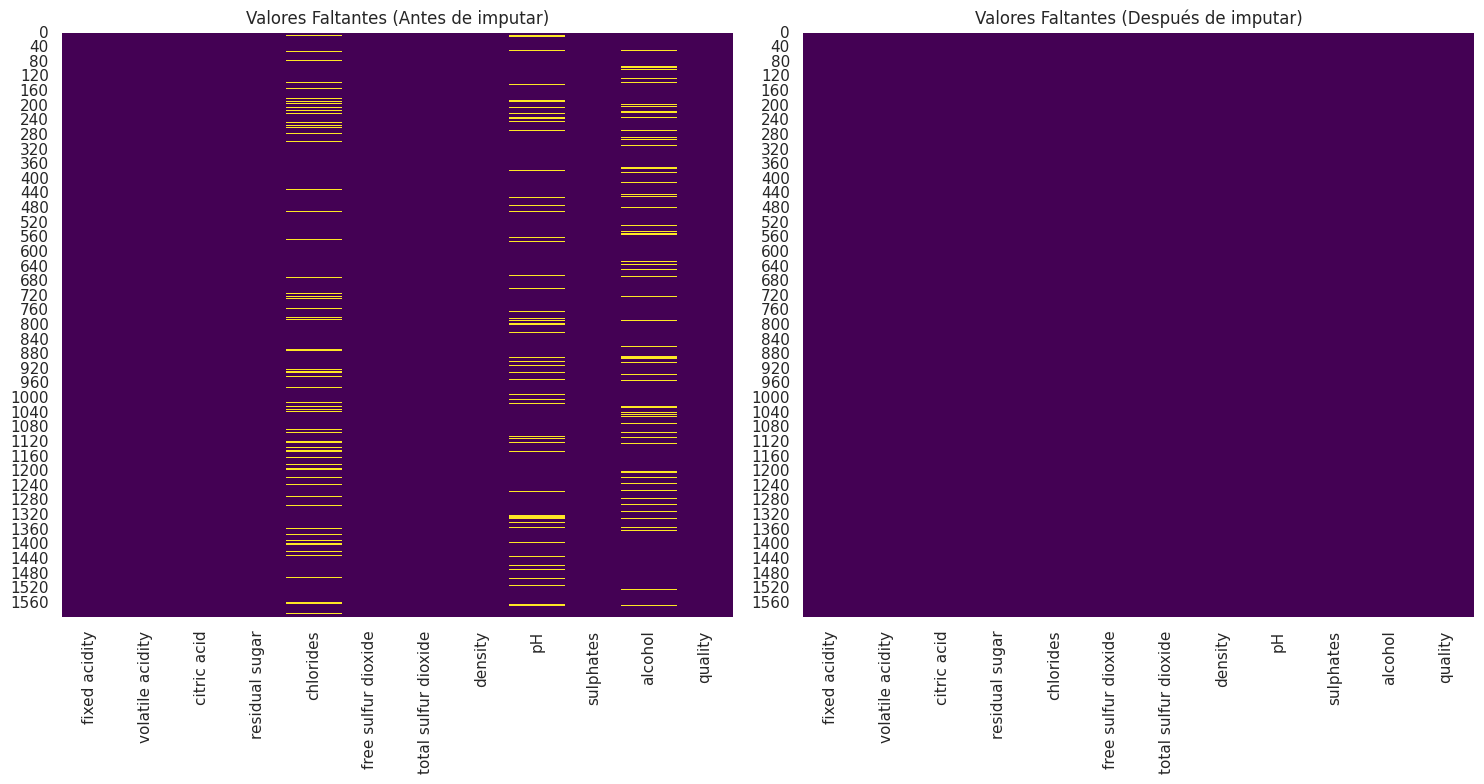

Total de nulos tras imputación: 0


In [ ]:
# ── CELDA 3

# 1. Introducir NaN
porcentaje_nan = 0.10
rng = np.random.default_rng(seed=42)
columnas_nan = ["alcohol", "pH", "chlorides"]

for col in columnas_nan:
    n_filas = int(len(datos_trabajo) * porcentaje_nan)
    indices = rng.choice(datos_trabajo.index, size=n_filas, replace=False)
    datos_trabajo.loc[indices, col] = np.nan

# 2. Visualización: Comparativa de mapas de calor (Antes vs Después)
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

sns.heatmap(datos_trabajo.isna(), cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Valores Faltantes (Antes de imputar)')

# 3. Imputación con la mediana
for col in columnas_nan:
    datos_trabajo[col] = datos_trabajo[col].fillna(datos_trabajo[col].median())

sns.heatmap(datos_trabajo.isna(), cbar=False, cmap='viridis', ax=axes[1])
axes[1].set_title('Valores Faltantes (Después de imputar)')

plt.tight_layout()
plt.show()

# Verificación rápida mediante un pequeño resumen
print("Total de nulos tras imputación:", datos_trabajo.isna().sum().sum())

### Normalización

=== ANTES DE NORMALIZACIÓN ===
                        count  mean   std  min   25%   50%   75%    max
fixed acidity        1,599.00  8.32  1.74 4.60  7.10  7.90  9.20  15.90
volatile acidity     1,599.00  0.53  0.18 0.12  0.39  0.52  0.64   1.58
citric acid          1,599.00  0.27  0.19 0.00  0.09  0.26  0.42   1.00
residual sugar       1,599.00  2.54  1.41 0.90  1.90  2.20  2.60  15.50
chlorides            1,599.00  0.09  0.04 0.01  0.07  0.08  0.09   0.61
free sulfur dioxide  1,599.00 15.87 10.46 1.00  7.00 14.00 21.00  72.00
total sulfur dioxide 1,599.00 46.47 32.90 6.00 22.00 38.00 62.00 289.00
density              1,599.00  1.00  0.00 0.99  1.00  1.00  1.00   1.00
pH                   1,599.00  3.31  0.15 2.74  3.22  3.31  3.39   4.01
sulphates            1,599.00  0.66  0.17 0.33  0.55  0.62  0.73   2.00
alcohol              1,599.00 10.38  1.01 8.40  9.55 10.10 11.00  14.90
quality              1,599.00  5.64  0.81 3.00  5.00  6.00  6.00   8.00


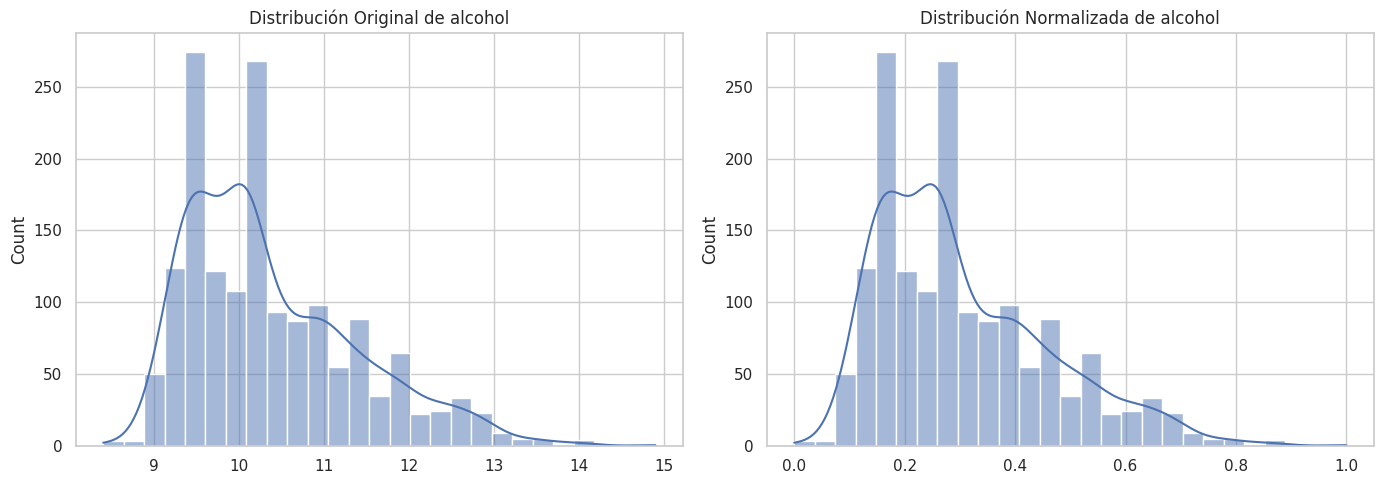


=== DESPUÉS DE NORMALIZACIÓN ===
                        count  mean  std  min  25%  50%  75%  max
fixed acidity        1,599.00  0.33 0.15 0.00 0.22 0.29 0.41 1.00
volatile acidity     1,599.00  0.28 0.12 0.00 0.18 0.27 0.36 1.00
citric acid          1,599.00  0.27 0.19 0.00 0.09 0.26 0.42 1.00
residual sugar       1,599.00  0.11 0.10 0.00 0.07 0.09 0.12 1.00
chlorides            1,599.00  0.12 0.07 0.00 0.10 0.11 0.13 1.00
free sulfur dioxide  1,599.00  0.21 0.15 0.00 0.08 0.18 0.28 1.00
total sulfur dioxide 1,599.00  0.14 0.12 0.00 0.06 0.11 0.20 1.00
density              1,599.00  0.49 0.14 0.00 0.41 0.49 0.57 1.00
pH                   1,599.00  0.45 0.12 0.00 0.38 0.45 0.51 1.00
sulphates            1,599.00  0.20 0.10 0.00 0.13 0.17 0.24 1.00
alcohol              1,599.00  0.31 0.16 0.00 0.18 0.26 0.40 1.00
quality              1,599.00  0.53 0.16 0.00 0.40 0.60 0.60 1.00


In [ ]:
# ── CELDA 4

# Copia antes de normalizar
datos_antes_normalizar = datos_trabajo.copy(deep=True)

# Ver estadísticos antes de normalizar
print("=== ANTES DE NORMALIZACIÓN ===")
print(datos_trabajo.describe().T)

# Aplicar MinMaxScaler
scaler = MinMaxScaler()
columnas_numericas = datos_trabajo.columns  # todas son numéricas
datos_trabajo[columnas_numericas] = scaler.fit_transform(datos_trabajo[columnas_numericas])

# Comparación visual para la variable 'alcohol'
variable = "alcohol"
original_data = datos_antes_normalizar[variable].values.reshape(-1, 1)
normalized_data = datos_trabajo[variable].values.reshape(-1, 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title(f"Distribución Original de {variable}")
sns.histplot(normalized_data, ax=ax[1], kde=True, legend=False)
ax[1].set_title(f"Distribución Normalizada de {variable}")
plt.tight_layout()
plt.show()

# Ver estadísticos después de normalizar
print("\n=== DESPUÉS DE NORMALIZACIÓN ===")
print(datos_trabajo.describe().T)

La normalización es un paso esencial en el preprocesamiento porque permite llevar todas las variables a la misma escala, evitando que aquellas con valores numéricamente mayores influyan desproporcionadamente en los modelos de Machine Learning. Al aplicar `MinMaxScaler`, todas las características se transforman al rango [0, 1], manteniendo su forma original pero haciendo que contribuyan de manera equilibrada al modelo. Esto mejora la estabilidad de los cálculos, acelera la convergencia y aumenta la precisión en algoritmos sensibles a la magnitud de los datos.

---
## 📊 FASE 4 (EDA): ANÁLISIS EXPLORATORIO
### Visualización de la Variable Objetivo y Distribuciones

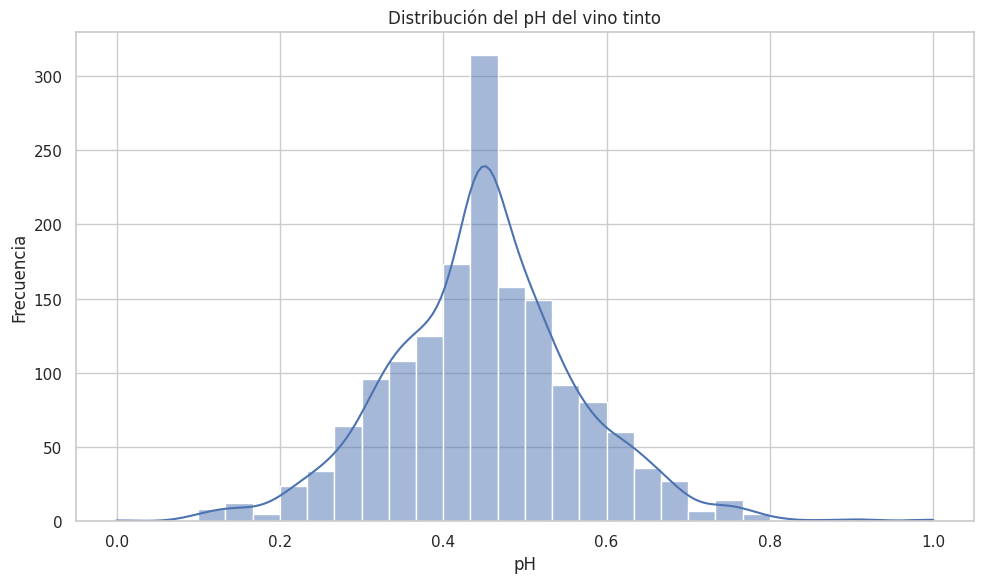

In [ ]:
# ── CELDA 5
plt.figure(figsize=(10, 6))
sns.histplot(datos_trabajo['pH'], kde=True, bins=30)
plt.title('Distribución del pH del vino tinto')
plt.xlabel('pH')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

#### 📊 Análisis: Distribución del pH del vino tinto

- La distribución del pH muestra una forma aproximadamente normal, con la mayor concentración de valores entre 3.1 y 3.4.
- Esto indica que la mayoría de los vinos presentan una acidez moderada y estable.
- Esta ligera simetría implica que el pH es una variable adecuada para el análisis y probablemente no requiere transformaciones adicionales.

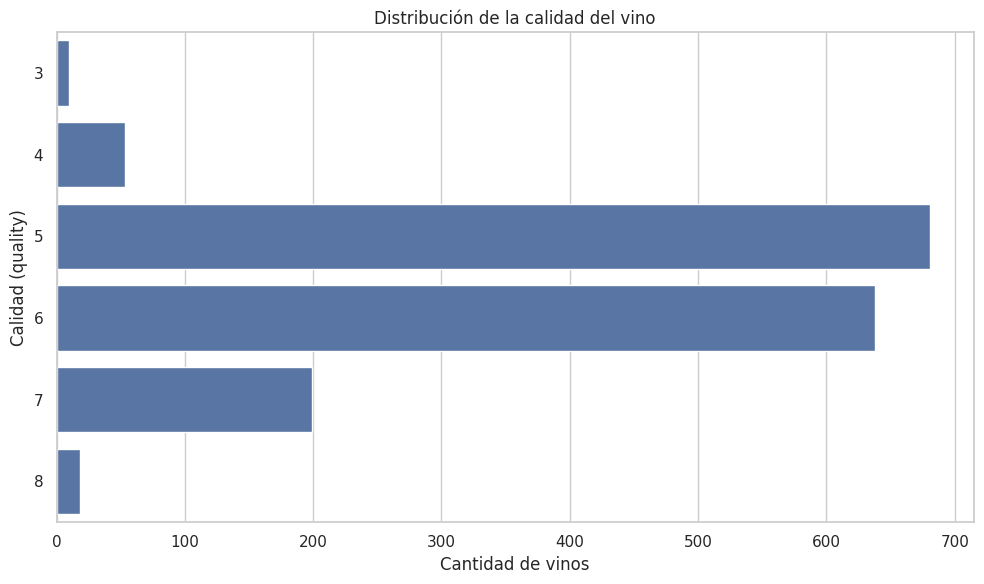

In [ ]:
# ── CELDA 6 
plt.figure(figsize=(10, 6))
sns.countplot(
    data=datos_trabajo,
    y='quality',
    order=datos_trabajo['quality'].value_counts().sort_index().index
)
plt.title('Distribución de la calidad del vino')
plt.xlabel('Cantidad de vinos')
plt.ylabel('Calidad (quality)')
plt.tight_layout()
plt.show()

#### 📊 Análisis: Distribución de la calidad del vino

- La calidad del vino se concentra principalmente en los valores 5 y 6, mientras que las calidades extremas como 3, 4, 7 y 8 aparecen con baja frecuencia.
- Este claro desequilibrio de clases puede dificultar que un modelo predictivo aprenda patrones en los valores menos representados.
- Esto significa que el modelo tenderá a predecir valores centrales a menos que se utilicen técnicas de balanceo.

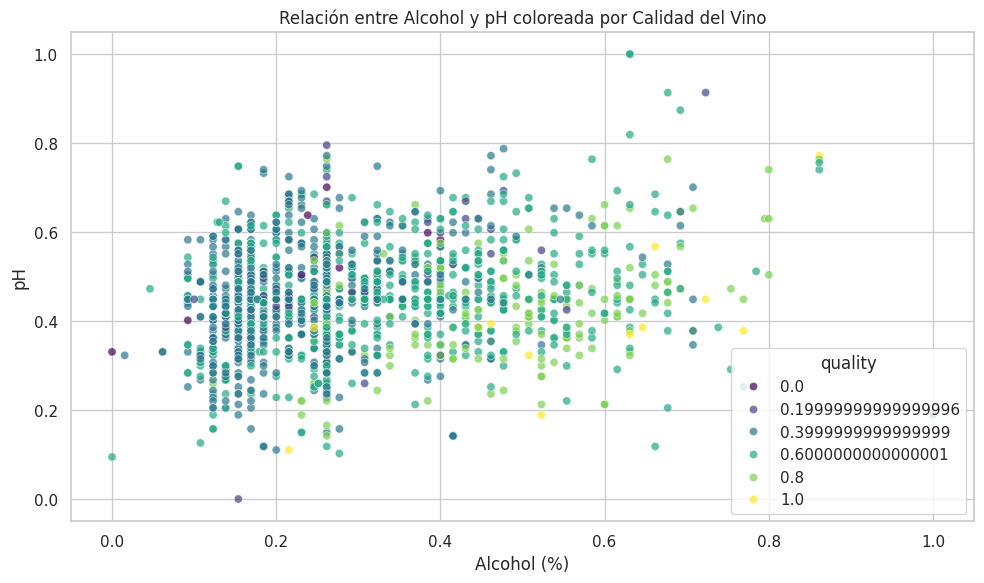

In [ ]:
# ── CELDA 7

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='alcohol',
    y='pH',
    hue='quality',
    data=datos_trabajo,
    palette='viridis',
    alpha=0.7
)
plt.title('Relación entre Alcohol y pH coloreada por Calidad del Vino')
plt.xlabel('Alcohol (%)')
plt.ylabel('pH')
plt.tight_layout()
plt.show()

#### 📊 Análisis: Relación entre Alcohol y pH coloreada por Nivel de Calidad

- El gráfico muestra que no existe una relación lineal fuerte entre el alcohol y el pH, ya que los puntos aparecen dispersos sin una tendencia clara.
- Sin embargo, los vinos de mayor calidad tienden a concentrarse en valores ligeramente más altos de alcohol.
- Esto sugiere que, aunque el pH no está directamente relacionado con el alcohol, el contenido alcohólico podría influir más significativamente en la calidad del vino.

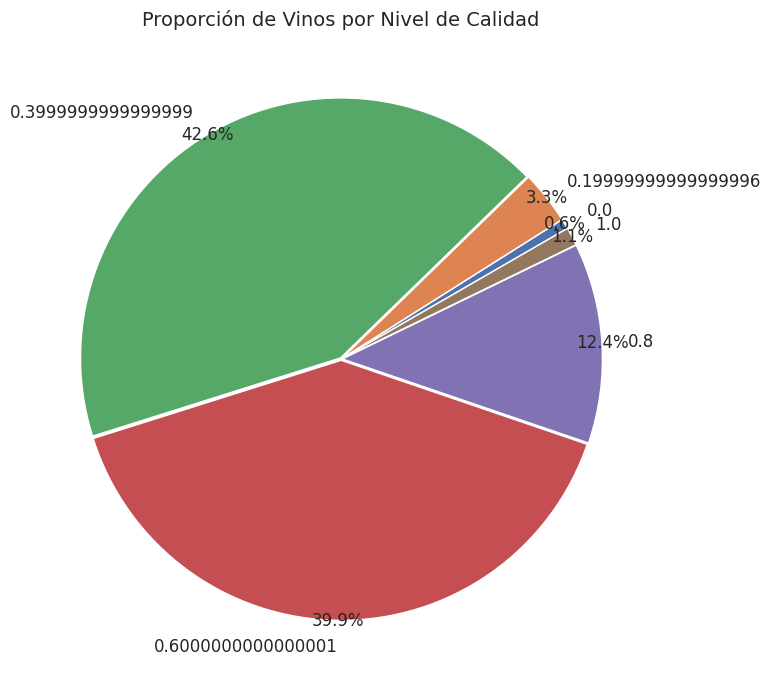

In [ ]:
# ── CELDA 8
valores = datos_trabajo['quality'].value_counts().sort_index()
labels = valores.index.astype(str)
explode = [0.005] * len(valores)

plt.figure(figsize=(8, 10))
plt.pie(
    valores,
    labels=labels,
    autopct='%1.1f%%',
    explode=explode,
    startangle=2190,
    pctdistance=1,
    labeldistance=1.1,
    textprops={'fontsize': 12}
)
plt.title('Proporción de Vinos por Nivel de Calidad', fontsize=14)
plt.tight_layout()
plt.show()

#### 📊 Análisis: Proporción de Vinos por Nivel de Calidad

- La gráfica de pastel confirma que las calidades 5 y 6 representan más del 80% de los vinos analizados.
- Las calidades altas (7 y 8) y bajas (3 y 4) tienen una presencia mínima, lo cual refuerza la existencia de un fuerte desequilibrio en los datos.
- Para el análisis predictivo, esto implica que un modelo puede presentar sesgos hacia los valores centrales si no se implementan técnicas de ajuste o balanceo.

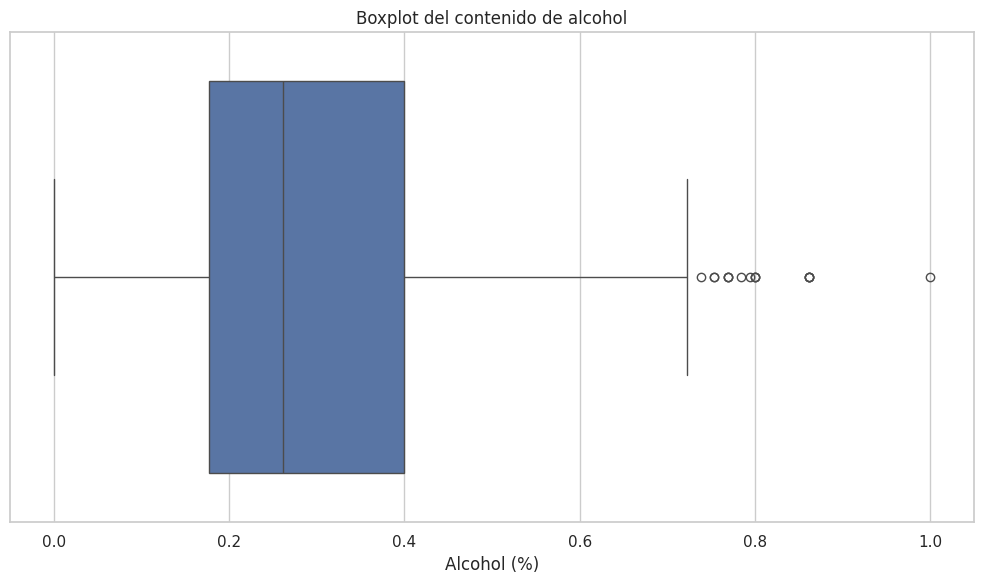

In [ ]:
# ── CELDA 9
plt.figure(figsize=(10, 6))
sns.boxplot(data=datos_trabajo, x='alcohol')
plt.title('Boxplot del contenido de alcohol')
plt.xlabel('Alcohol (%)')
plt.tight_layout()
plt.show()

#### 📊 Análisis: Boxplot del Contenido de Alcohol

- El boxplot revela que la mayoría de los vinos tienen un contenido de alcohol entre aproximadamente 9.5% y 11.5%, con varios outliers que superan estos valores llegando hasta casi 15%.
- Estos valores extremos pueden influir significativamente en modelos sensibles, especialmente en algoritmos lineales.
- Esto resalta la importancia de aplicar un escalado adecuado y considerar técnicas para mitigar el impacto de los outliers.

### Matriz de Correlación (Spearman)

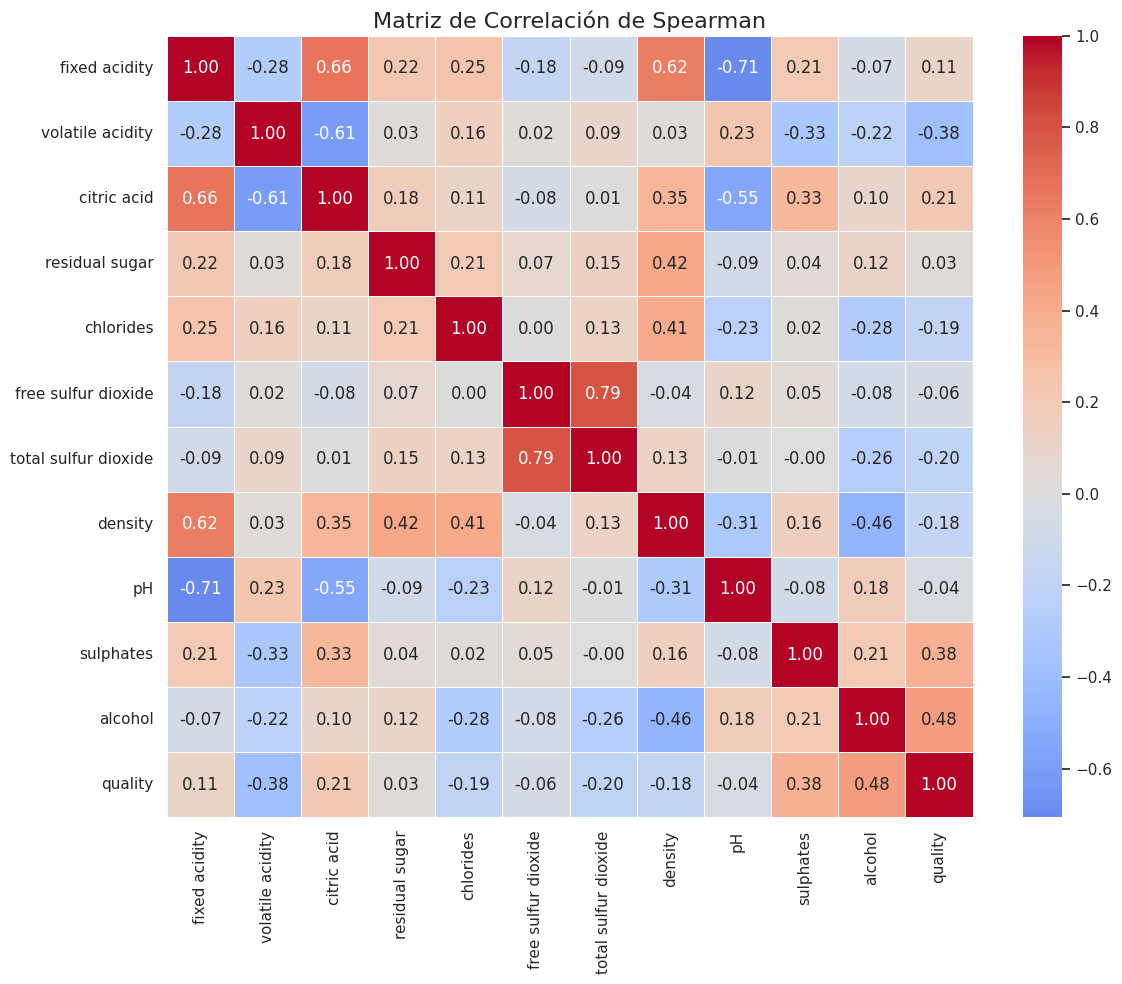


=== CORRELACIONES MÁS FUERTES ===
free sulfur dioxide ↔ total sulfur dioxide: 0.790
fixed acidity ↔ pH: -0.707
fixed acidity ↔ citric acid: 0.662


In [ ]:
# ── CELDA 10

# Calcular matriz de correlación
correlacion = datos_trabajo.corr(method='spearman')

# Visualizar con heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlacion, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, center=0)
plt.title('Matriz de Correlación de Spearman', fontsize=16)
plt.tight_layout()
plt.show()

# Identificar correlaciones fuertes
print("\n=== CORRELACIONES MÁS FUERTES ===")

correlaciones_fuertes = []
columnas = correlacion.columns

for i in range(len(columnas)):
    for j in range(i + 1, len(columnas)):
        valor = correlacion.iloc[i, j]
        if abs(valor) >= 0.5:
            correlaciones_fuertes.append((columnas[i], columnas[j], valor))

correlaciones_ordenadas = sorted(
    correlaciones_fuertes, key=lambda x: abs(x[2]), reverse=True
)

for var1, var2, corr in correlaciones_ordenadas[:3]:
    print(f"{var1} ↔ {var2}: {corr:.3f}")

La matriz de correlación de Spearman permite identificar relaciones monótonas entre las variables del vino, siendo robusta ante valores atípicos y útil incluso cuando las relaciones no son lineales. En el dataset se observan correlaciones particularmente fuertes entre algunas variables, como la relación negativa entre *alcohol* y *density*, lo cual es esperable porque mayor alcohol disminuye la densidad del vino.

También destacan correlaciones positivas como *fixed acidity* con *citric acid*, indicando que ambas medidas químicas aumentan de forma similar. Asimismo, se observa que *alcohol* mantiene una correlación positiva con *quality*, sugiriendo que vinos con mayor graduación alcohólica tienden a recibir mejores puntuaciones.

### Test de Normalidad (Shapiro-Wilk)

In [ ]:
# ── CELDA  11
from scipy.stats import shapiro
import pandas as pd

def test_normalidad(dataframe, alpha=0.05):
    print("=== TEST DE SHAPIRO-WILK ===")
    print(f"Nivel de significancia (alpha): {alpha}\n")

    for col in dataframe.columns:
        if pd.api.types.is_numeric_dtype(dataframe[col]):
            data = dataframe[col].dropna()

            if len(data) >= 3:
                stat, p_value = shapiro(data)
                resultado = "NORMAL" if p_value > alpha else "NO NORMAL"

                print(f"\nVariable: {col}")
                print(f" Estadístico W: {stat:.4f}")
                print(f" P-valor: {p_value:.4f}")
                print(f" Conclusión: {resultado}")
                print("-" * 40)

# Aplicar el test a los datos normalizados
test_normalidad(datos_trabajo)

=== TEST DE SHAPIRO-WILK ===
Nivel de significancia (alpha): 0.05


Variable: fixed acidity
 Estadístico W: 0.9420
 P-valor: 0.0000
 Conclusión: NO NORMAL
----------------------------------------

Variable: volatile acidity
 Estadístico W: 0.9743
 P-valor: 0.0000
 Conclusión: NO NORMAL
----------------------------------------

Variable: citric acid
 Estadístico W: 0.9553
 P-valor: 0.0000
 Conclusión: NO NORMAL
----------------------------------------

Variable: residual sugar
 Estadístico W: 0.5661
 P-valor: 0.0000
 Conclusión: NO NORMAL
----------------------------------------

Variable: chlorides
 Estadístico W: 0.4908
 P-valor: 0.0000
 Conclusión: NO NORMAL
----------------------------------------

Variable: free sulfur dioxide
 Estadístico W: 0.9018
 P-valor: 0.0000
 Conclusión: NO NORMAL
----------------------------------------

Variable: total sulfur dioxide
 Estadístico W: 0.8732
 P-valor: 0.0000
 Conclusión: NO NORMAL
----------------------------------------

Variable: density


El test de Shapiro–Wilk aplicado a todas las variables numéricas del dataset indica que **ninguna de ellas sigue una distribución normal**, ya que en todos los casos el p-valor fue menor que el nivel de significancia (α = 0.05). Esto es completamente esperado, ya que las variables químicas suelen presentar distribuciones sesgadas y con colas largas, mientras que *quality* es una variable discreta y, por tanto, no puede ajustarse a una distribución normal continua.

Además, debido al gran tamaño de la muestra (1,599 observaciones), el test de Shapiro–Wilk se vuelve muy sensible y detecta incluso pequeñas desviaciones respecto a la normalidad. Estas conclusiones refuerzan la decisión de utilizar técnicas estadísticas robustas y métodos de correlación como Spearman, que no dependen del supuesto de normalidad.

---
## 🤖 FASE 4: REGRESIÓN LINEAL SIMPLE
### Split Train/Test (predictor: `citric acid`)

In [ ]:
# ── CELDA  12

from sklearn.model_selection import train_test_split

# Variable predictora y objetivo para regresión simple
X_simple = datos_trabajo[['citric acid']]
y_simple  = datos_trabajo['quality']

# División 80 % entrenamiento / 20 % prueba
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

print("=== SPLIT TRAIN / TEST (Regresión Simple) ===")
print(f"Total de muestras  : {len(X_simple)}")
print(f"Entrenamiento (80%): {len(X_train_s)} muestras")
print(f"Prueba        (20%): {len(X_test_s)} muestras")
print(f"\nPredictor : citric acid")
print(f"Objetivo  : quality")

# Vista rápida de los conjuntos
print("\n--- Estadísticos X_train_s ---")
display(X_train_s.describe())
print("--- Estadísticos X_test_s ---")
display(X_test_s.describe())

=== SPLIT TRAIN / TEST (Regresión Simple) ===
Total de muestras  : 1599
Entrenamiento (80%): 1279 muestras
Prueba        (20%): 320 muestras

Predictor : citric acid
Objetivo  : quality

--- Estadísticos X_train_s ---


,citric acid
count,"1,279.00"
mean,0.27
std,0.20
min,0.00
25%,0.10
50%,0.26
75%,0.43
max,1.00


--- Estadísticos X_test_s ---


,citric acid
count,320.00
mean,0.27
std,0.19
min,0.00
25%,0.08
50%,0.25
75%,0.41
max,0.79


### Entrenamiento del Modelo Simple

In [33]:
from sklearn.linear_model import LinearRegression

# Crear y entrenar el modelo de regresión simple
modelo_simple = LinearRegression()
modelo_simple.fit(X_train_s, y_train_s)

# Predicciones sobre el conjunto de prueba
y_pred_s = modelo_simple.predict(X_test_s)

print("=== PARÁMETROS DEL MODELO SIMPLE ===")
print(f"Intercepto (β₀)        : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ (citric acid): {modelo_simple.coef_[0]:.4f}")
print(f"\nEcuación aprendida:")
print(f"  quality = {modelo_simple.intercept_:.4f} + ({modelo_simple.coef_[0]:.4f}) × citric_acid")

=== PARÁMETROS DEL MODELO SIMPLE ===
Intercepto (β₀)        : 0.4762
Coeficiente β₁ (citric acid): 0.1784

Ecuación aprendida:
  quality = 0.4762 + (0.1784) × citric_acid


### Gráfica de la Recta de Regresión (Visualización del Ajuste)

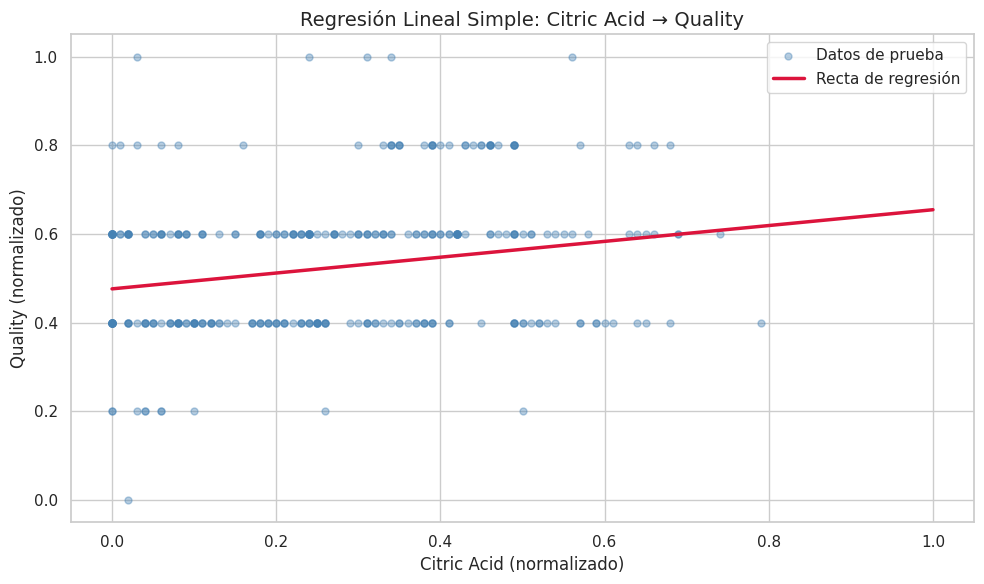

In [ ]:
# ── CELDA  13

import matplotlib.pyplot as plt
import numpy as np

# Rango de valores para dibujar la recta
x_range = np.linspace(X_simple['citric acid'].min(), X_simple['citric acid'].max(), 200).reshape(-1, 1)
y_range = modelo_simple.predict(x_range)

plt.figure(figsize=(10, 6))
plt.scatter(X_test_s, y_test_s, alpha=0.4, color='steelblue', label='Datos de prueba', s=25)
plt.plot(x_range, y_range, color='crimson', linewidth=2.5, label='Recta de regresión')
plt.xlabel('Citric Acid (normalizado)', fontsize=12)
plt.ylabel('Quality (normalizado)', fontsize=12)
plt.title('Regresión Lineal Simple: Citric Acid → Quality', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Métricas del Modelo Simple (R², MSE, RMSE, MAE)

In [ ]:
# ── CELDA  14
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

mse_s   = mean_squared_error(y_test_s, y_pred_s)
rmse_s  = np.sqrt(mse_s)
mae_s   = mean_absolute_error(y_test_s, y_pred_s)
r2_s    = r2_score(y_test_s, y_pred_s)

print("=" * 45)
print("  MÉTRICAS — MODELO DE REGRESIÓN SIMPLE")
print("=" * 45)
print(f"  R²   (Coef. de determinación) : {r2_s:.4f}")
print(f"  MSE  (Error cuadrático medio)  : {mse_s:.4f}")
print(f"  RMSE (Raíz del MSE)            : {rmse_s:.4f}")
print(f"  MAE  (Error absoluto medio)    : {mae_s:.4f}")
print("=" * 45)
print(f"\nInterpretación R²: el modelo explica el {r2_s*100:.2f}% de la")
print("variabilidad de 'quality' usando solo 'citric acid'.")

  MÉTRICAS — MODELO DE REGRESIÓN SIMPLE
  R²   (Coef. de determinación) : 0.0631
  MSE  (Error cuadrático medio)  : 0.0245
  RMSE (Raíz del MSE)            : 0.1565
  MAE  (Error absoluto medio)    : 0.1307

Interpretación R²: el modelo explica el 6.31% de la
variabilidad de 'quality' usando solo 'citric acid'.


###  Resumen OLS con `statsmodels` (Análisis Estadístico Detallado)

In [ ]:
# ── CELDA  15

import statsmodels.api as sm

# statsmodels requiere añadir la constante (intercepto) manualmente
X_train_sm = sm.add_constant(X_train_s)

# Ajustar modelo OLS sobre el conjunto de entrenamiento
ols_simple = sm.OLS(y_train_s, X_train_sm).fit()

# Mostrar el resumen completo
print(ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     62.57
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           5.54e-15
Time:                        21:12:40   Log-Likelihood:                 549.14
No. Observations:                1279   AIC:                            -1094.
Df Residuals:                    1277   BIC:                            -1084.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.4762      0.008     62.952      

### Normalidad de Residuos (Histograma + Q-Q Plot + Shapiro-Wilk)

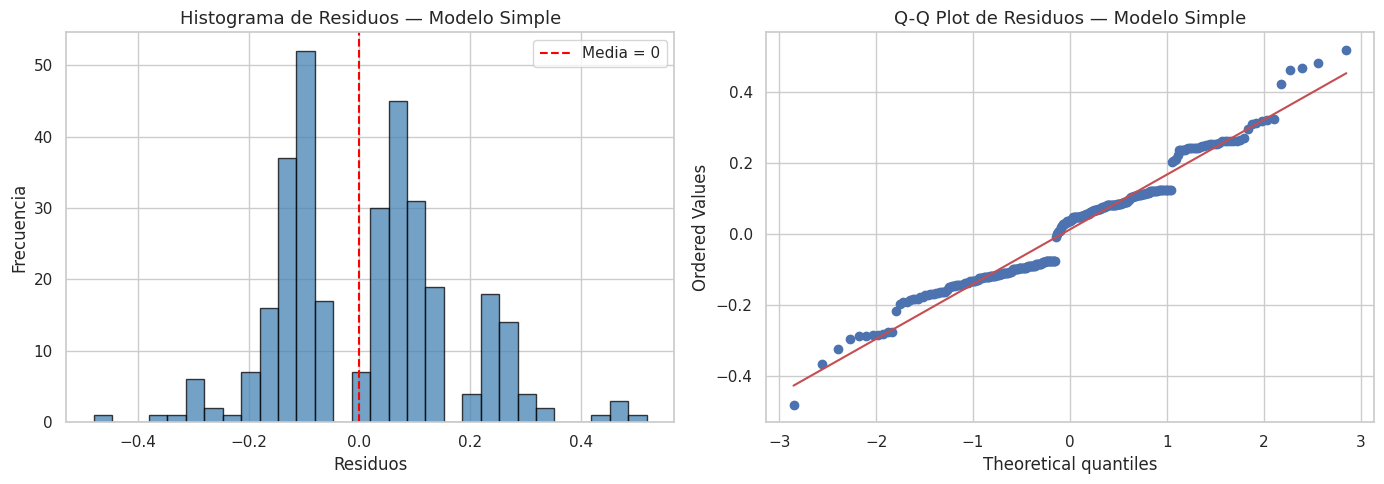


=== TEST DE SHAPIRO-WILK SOBRE RESIDUOS ===
  Estadístico W : 0.9642
  P-valor        : 0.0000
  Conclusión     : Los residuos son NO NORMAL (p ≤ 0.05)


In [ ]:
# ── CELDA  16

import scipy.stats as stats
import matplotlib.pyplot as plt

# Calcular residuos del conjunto de prueba
residuos_s = y_test_s - y_pred_s

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Histograma de residuos ──────────────────────────────────────────────────
axes[0].hist(residuos_s, bins=30, edgecolor='black', color='steelblue', alpha=0.75)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Media = 0')
axes[0].set_title('Histograma de Residuos — Modelo Simple', fontsize=13)
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# ── Q-Q Plot ────────────────────────────────────────────────────────────────
stats.probplot(residuos_s, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot de Residuos — Modelo Simple', fontsize=13)

plt.tight_layout()
plt.show()

# ── Test de Shapiro-Wilk sobre los residuos ─────────────────────────────────
stat_res, p_res = stats.shapiro(residuos_s)
print("\n=== TEST DE SHAPIRO-WILK SOBRE RESIDUOS ===")
print(f"  Estadístico W : {stat_res:.4f}")
print(f"  P-valor        : {p_res:.4f}")
conclusion = "NORMAL (p > 0.05)" if p_res > 0.05 else "NO NORMAL (p ≤ 0.05)"
print(f"  Conclusión     : Los residuos son {conclusion}")

### Homocedasticidad (Residuos vs Ajustados + Breusch-Pagan)

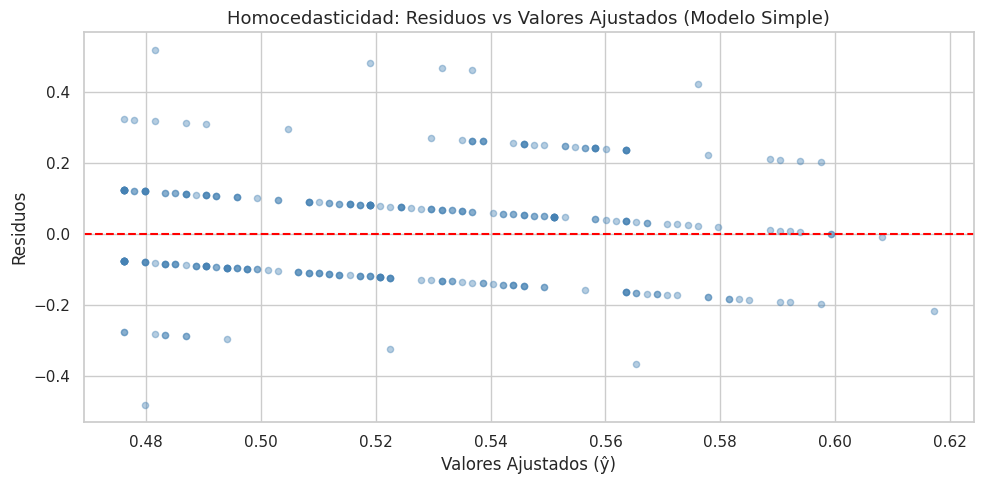


=== TEST DE BREUSCH-PAGAN (Homocedasticidad) ===
  LM Statistic        : 0.8469
  LM p-value          : 0.3574
  F-statistic         : 0.8439
  F p-value           : 0.3590

  → Conclusión: No se rechaza HOMOCEDASTICIDAD (p > 0.05).
    La varianza de los residuos es aproximadamente constante.


In [ ]:
# ── CELDA  17

from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# ── Gráfico: Residuos vs Valores Ajustados ──────────────────────────────────
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_s, residuos_s, alpha=0.4, color='steelblue', s=20)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Homocedasticidad: Residuos vs Valores Ajustados (Modelo Simple)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Test de Breusch-Pagan ────────────────────────────────────────────────────
X_test_sm_bp = sm.add_constant(X_test_s)
bp_test = het_breuschpagan(residuos_s, X_test_sm_bp)
labels_bp = ['LM Statistic', 'LM p-value', 'F-statistic', 'F p-value']

print("\n=== TEST DE BREUSCH-PAGAN (Homocedasticidad) ===")
for label, value in zip(labels_bp, bp_test):
    print(f"  {label:20s}: {value:.4f}")

p_bp = bp_test[1]
if p_bp < 0.05:
    print("\n  → Conclusión: Se detecta HETEROCEDASTICIDAD (p ≤ 0.05).")
    print("    La varianza de los residuos NO es constante.")
else:
    print("\n  → Conclusión: No se rechaza HOMOCEDASTICIDAD (p > 0.05).")
    print("    La varianza de los residuos es aproximadamente constante.")

---
## 🤖 FASE 5: REGRESIÓN MÚLTIPLE + DIAGNÓSTICO
###  Entrenamiento del Modelo Múltiple OLS

In [ ]:
# ── CELDA  18

import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# ── Variables predictoras y objetivo ────────────────────────────────────────
X_mult = datos_trabajo.drop('quality', axis=1)
y_mult = datos_trabajo['quality']

# División 80/20
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mult, y_mult, test_size=0.2, random_state=42
)

# ── sklearn: para predicciones ──────────────────────────────────────────────
modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train_m, y_train_m)
y_pred_m = modelo_multiple.predict(X_test_m)

# ── statsmodels OLS: para análisis estadístico ──────────────────────────────
X_train_sm_m = sm.add_constant(X_train_m)
ols_multiple = sm.OLS(y_train_m, X_train_sm_m).fit()

print("=== MODELO MÚLTIPLE ENTRENADO ===")
print(f"Número de predictores  : {X_mult.shape[1]}")
print(f"Muestras entrenamiento : {len(X_train_m)}")
print(f"Muestras prueba        : {len(X_test_m)}")
print(f"\nVariables incluidas:")
for col in X_mult.columns:
    print(f"  • {col}")

=== MODELO MÚLTIPLE ENTRENADO ===
Número de predictores  : 11
Muestras entrenamiento : 1279
Muestras prueba        : 320

Variables incluidas:
  • fixed acidity
  • volatile acidity
  • citric acid
  • residual sugar
  • chlorides
  • free sulfur dioxide
  • total sulfur dioxide
  • density
  • pH
  • sulphates
  • alcohol


### Gráfica Comparativa de Coeficientes (Importancia de Variables)

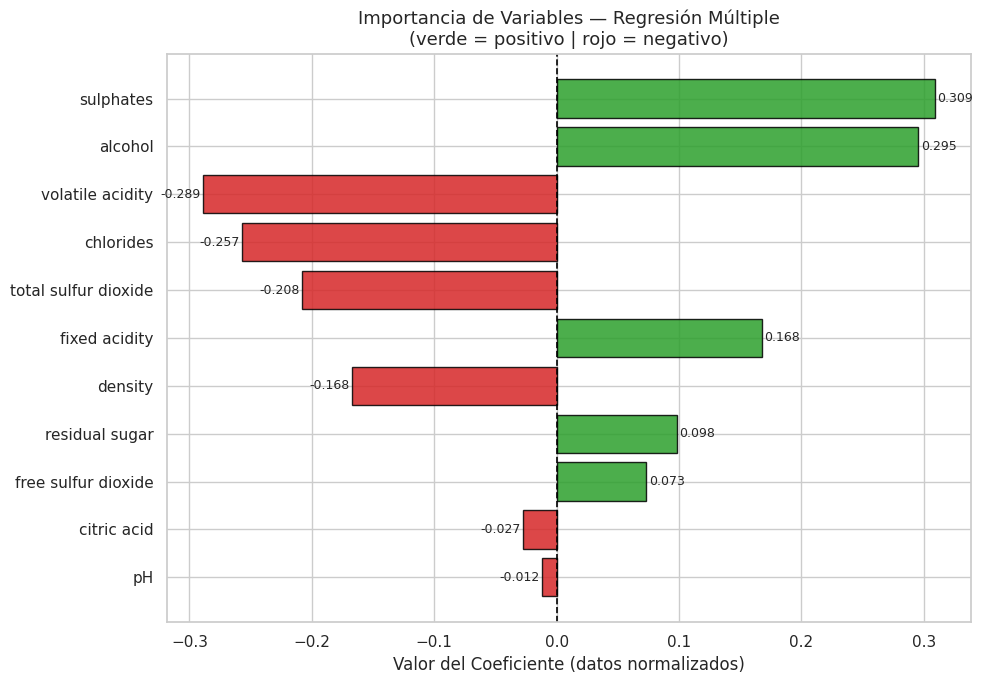


=== COEFICIENTES ORDENADOS POR MAGNITUD ===


,Variable,Coeficiente
0,sulphates,0.31
1,alcohol,0.30
2,volatile acidity,-0.29
3,chlorides,-0.26
4,total sulfur dioxide,-0.21
5,fixed acidity,0.17
6,density,-0.17
7,residual sugar,0.10
8,free sulfur dioxide,0.07
9,citric acid,-0.03


In [ ]:
# ── CELDA  19

import pandas as pd
import matplotlib.pyplot as plt

# DataFrame de coeficientes ordenados por valor absoluto
coef_df = pd.DataFrame({
    'Variable'   : X_mult.columns,
    'Coeficiente': modelo_multiple.coef_
}).sort_values('Coeficiente', key=abs, ascending=True)

# Asignar colores según signo del coeficiente
colores = ['#d62728' if c < 0 else '#2ca02c' for c in coef_df['Coeficiente']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(coef_df['Variable'], coef_df['Coeficiente'], color=colores, edgecolor='black', alpha=0.85)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Valor del Coeficiente (datos normalizados)', fontsize=12)
ax.set_title('Importancia de Variables — Regresión Múltiple\n(verde = positivo | rojo = negativo)', fontsize=13)

# Anotar valores en las barras
for bar, val in zip(bars, coef_df['Coeficiente']):
    ax.text(
        val + (0.002 if val >= 0 else -0.002),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}', va='center',
        ha='left' if val >= 0 else 'right', fontsize=9
    )

plt.tight_layout()
plt.show()

print("\n=== COEFICIENTES ORDENADOS POR MAGNITUD ===")
display(coef_df.sort_values('Coeficiente', key=abs, ascending=False).reset_index(drop=True))

### Métricas del Modelo Múltiple

In [ ]:
# ── CELDA  19

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

mse_m  = mean_squared_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_m)
r2_m   = r2_score(y_test_m, y_pred_m)

print("=" * 47)
print("  MÉTRICAS — MODELO DE REGRESIÓN MÚLTIPLE")
print("=" * 47)
print(f"  R²   (Coef. de determinación) : {r2_m:.4f}")
print(f"  MSE  (Error cuadrático medio)  : {mse_m:.4f}")
print(f"  RMSE (Raíz del MSE)            : {rmse_m:.4f}")
print(f"  MAE  (Error absoluto medio)    : {mae_m:.4f}")
print("=" * 47)
print(f"\nEl modelo explica el {r2_m*100:.2f}% de la variabilidad")
print("de 'quality' usando TODAS las variables fisicoquímicas.")

  MÉTRICAS — MODELO DE REGRESIÓN MÚLTIPLE
  R²   (Coef. de determinación) : 0.3931
  MSE  (Error cuadrático medio)  : 0.0159
  RMSE (Raíz del MSE)            : 0.1259
  MAE  (Error absoluto medio)    : 0.1011

El modelo explica el 39.31% de la variabilidad
de 'quality' usando TODAS las variables fisicoquímicas.


###  Resumen OLS `statsmodels` (Comparativa Técnica frente al Simple)

In [ ]:
# ── CELDA  20

# Mostrar resumen completo del modelo múltiple
print(ols_multiple.summary())

# Comparativa rápida de métricas estadísticas: Simple vs Múltiple
print("\n" + "=" * 55)
print("  COMPARATIVA ESTADÍSTICA: SIMPLE vs MÚLTIPLE (OLS)")
print("=" * 55)
print(f"  {'Métrica':<30} {'Simple':>10} {'Múltiple':>10}")
print("-" * 55)

# OLS sobre conjunto de entrenamiento del modelo simple
print(f"  {'R² (train)':<30} {ols_simple.rsquared:>10.4f} {ols_multiple.rsquared:>10.4f}")
print(f"  {'R² ajustado (train)':<30} {ols_simple.rsquared_adj:>10.4f} {ols_multiple.rsquared_adj:>10.4f}")
print(f"  {'AIC':<30} {ols_simple.aic:>10.2f} {ols_multiple.aic:>10.2f}")
print(f"  {'BIC':<30} {ols_simple.bic:>10.2f} {ols_multiple.bic:>10.2f}")
print(f"  {'F-statistic (p-value)':<30} {ols_simple.f_pvalue:>10.4f} {ols_multiple.f_pvalue:>10.4f}")
print("=" * 55)

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     58.05
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          3.01e-104
Time:                        21:12:42   Log-Likelihood:                 779.56
No. Observations:                1279   AIC:                            -1535.
Df Residuals:                    1267   BIC:                            -1473.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.5305 

### VIF: Diagnóstico de Multicolinealidad

=== FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) ===


,Variable,VIF,Nivel
0,fixed acidity,6.02,Moderado ⚠️
1,density,4.87,Bajo ✅
2,citric acid,3.06,Bajo ✅
3,pH,2.63,Bajo ✅
4,alcohol,2.34,Bajo ✅
5,total sulfur dioxide,2.17,Bajo ✅
6,free sulfur dioxide,1.97,Bajo ✅
7,volatile acidity,1.76,Bajo ✅
8,residual sugar,1.57,Bajo ✅
9,sulphates,1.37,Bajo ✅


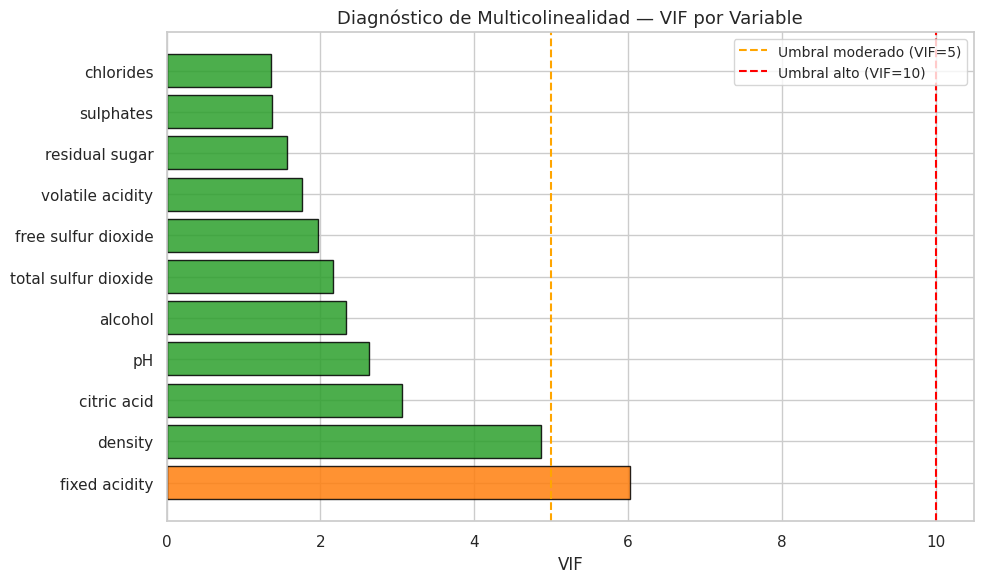

In [ ]:
# ── CELDA  21

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Calcular VIF para cada predictor
X_vif = sm.add_constant(X_train_m)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

# Excluir constante de la visualización
vif_data = vif_data[vif_data['Variable'] != 'const'].sort_values('VIF', ascending=False)

# Clasificar por nivel de riesgo
def clasificar_vif(v):
    if v < 5:   return 'Bajo ✅'
    elif v < 10: return 'Moderado ⚠️'
    else:        return 'Alto 🔴'

vif_data['Nivel'] = vif_data['VIF'].apply(clasificar_vif)

print("=== FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) ===")
display(vif_data.reset_index(drop=True))

# Gráfico de barras VIF
colores_vif = ['#d62728' if v >= 10 else '#ff7f0e' if v >= 5 else '#2ca02c'
               for v in vif_data['VIF']]

plt.figure(figsize=(10, 6))
plt.barh(vif_data['Variable'], vif_data['VIF'], color=colores_vif, edgecolor='black', alpha=0.85)
plt.axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='Umbral moderado (VIF=5)')
plt.axvline(10, color='red',    linestyle='--', linewidth=1.5, label='Umbral alto (VIF=10)')
plt.xlabel('VIF', fontsize=12)
plt.title('Diagnóstico de Multicolinealidad — VIF por Variable', fontsize=13)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

###  Diagnósticos Completos del Modelo Múltiple (Normalidad y Homocedasticidad)

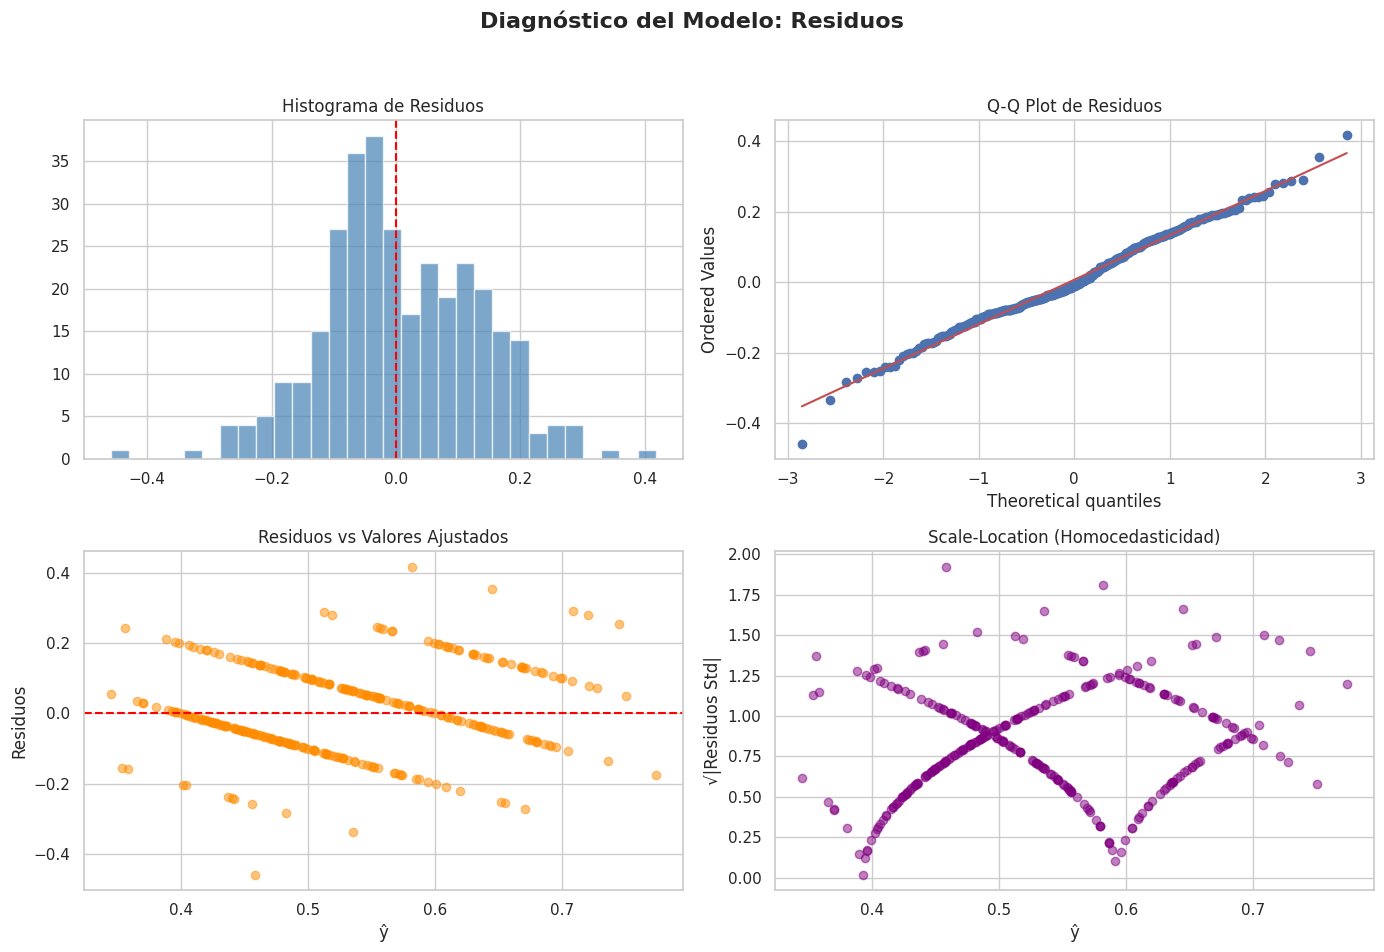


=== RESUMEN DE DIAGNÓSTICOS ===


,Test,Estadístico,p-valor,Conclusión
0,Shapiro-Wilk (Normalidad),0.99,0.10,Normal
1,Breusch-Pagan (Homocedasticidad),30.22,0.00,Heterocedástico


In [36]:
# ── CELDA  22
import pandas as pd
import numpy as np
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Configuración de residuos
residuos_m = y_test_m.values - y_pred_m
residuos_std = np.sqrt(np.abs((residuos_m - residuos_m.mean()) / residuos_m.std()))

# 2. Diagnóstico visual
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diagnóstico del Modelo: Residuos', fontsize=16, fontweight='bold')

# Histograma
axes[0,0].hist(residuos_m, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[0,0].axvline(0, color='red', linestyle='--')
axes[0,0].set_title('Histograma de Residuos')

# Q-Q Plot
stats.probplot(residuos_m, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot de Residuos')

# Residuos vs Ajustados
axes[1,0].scatter(y_pred_m, residuos_m, alpha=0.5, color='darkorange')
axes[1,0].axhline(0, color='red', linestyle='--')
axes[1,0].set_title('Residuos vs Valores Ajustados')
axes[1,0].set(xlabel='ŷ', ylabel='Residuos')

# Scale-Location
axes[1,1].scatter(y_pred_m, residuos_std, alpha=0.5, color='purple')
axes[1,1].set_title('Scale-Location (Homocedasticidad)')
axes[1,1].set(xlabel='ŷ', ylabel='√|Residuos Std|')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. Resumen Estadístico
shapiro_stat, shapiro_p = stats.shapiro(residuos_m)
X_test_sm = sm.add_constant(X_test_m)
bp_test = het_breuschpagan(residuos_m, X_test_sm)

df_resultados = pd.DataFrame({
    'Test': ['Shapiro-Wilk (Normalidad)', 'Breusch-Pagan (Homocedasticidad)'],
    'Estadístico': [shapiro_stat, bp_test[0]],
    'p-valor': [shapiro_p, bp_test[1]],
    'Conclusión': [
        'Normal' if shapiro_p > 0.05 else 'No Normal',
        'Homocedástico' if bp_test[1] > 0.05 else 'Heterocedástico'
    ]
})

print("\n=== RESUMEN DE DIAGNÓSTICOS ===")
display(df_resultados)

---
## 📊 FASE 6: DIAGNÓSTICOS CONSOLIDADOS Y COMPARACIÓN DE MODELOS
### Tabla Comparativa de Métricas (Simple vs. Múltiple)

    TABLA COMPARATIVA DE MÉTRICAS — SIMPLE vs MÚLTIPLE


Modelo,Regresión Simple\n(citric acid),Regresión Múltiple\n(todas las variables)
R²,0.06,0.39
MSE,0.02,0.02
RMSE,0.16,0.13
MAE,0.13,0.10
N predictores,1.00,11.00
R² ajustado (train),0.05,0.33
AIC,"-1,094.28","-1,535.11"
BIC,"-1,083.97","-1,473.26"


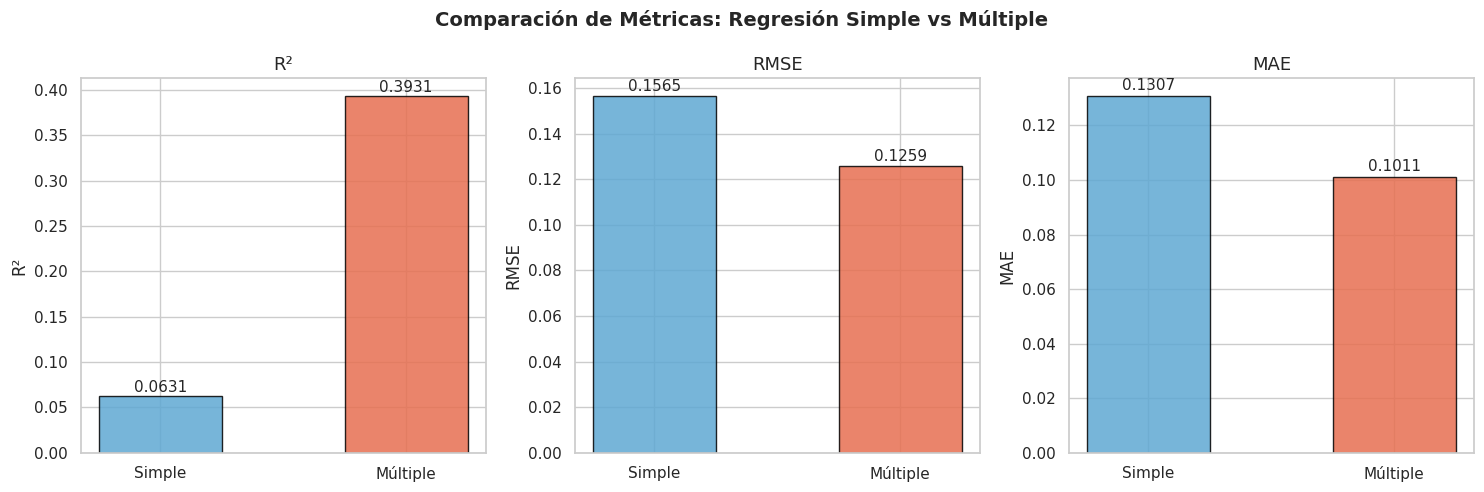

In [ ]:
# ── CELDA  23

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Calcular métricas para ambos modelos
metricas = {
    'Modelo': ['Regresión Simple\n(citric acid)', 'Regresión Múltiple\n(todas las variables)'],
    'R²':   [r2_score(y_test_s, y_pred_s),          r2_score(y_test_m, y_pred_m)],
    'MSE':  [mean_squared_error(y_test_s, y_pred_s), mean_squared_error(y_test_m, y_pred_m)],
    'RMSE': [np.sqrt(mean_squared_error(y_test_s, y_pred_s)), np.sqrt(mean_squared_error(y_test_m, y_pred_m))],
    'MAE':  [mean_absolute_error(y_test_s, y_pred_s), mean_absolute_error(y_test_m, y_pred_m)],
    'N predictores': [1, X_mult.shape[1]],
    'R² ajustado (train)': [ols_simple.rsquared_adj, ols_multiple.rsquared_adj],
    'AIC': [ols_simple.aic, ols_multiple.aic],
    'BIC': [ols_simple.bic, ols_multiple.bic],
}

df_metricas = pd.DataFrame(metricas).set_index('Modelo')
print("=" * 65)
print("    TABLA COMPARATIVA DE MÉTRICAS — SIMPLE vs MÚLTIPLE")
print("=" * 65)
display(df_metricas.T)

# ── Visualización: Barras comparativas para R², RMSE y MAE ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparación de Métricas: Regresión Simple vs Múltiple', fontsize=14, fontweight='bold')

modelos = ['Simple', 'Múltiple']
metricas_plot = [
    ('R²',   [r2_score(y_test_s, y_pred_s), r2_score(y_test_m, y_pred_m)],   ['#5fa8d3', '#e76f51']),
    ('RMSE', [np.sqrt(mean_squared_error(y_test_s, y_pred_s)), np.sqrt(mean_squared_error(y_test_m, y_pred_m))], ['#5fa8d3', '#e76f51']),
    ('MAE',  [mean_absolute_error(y_test_s, y_pred_s), mean_absolute_error(y_test_m, y_pred_m)], ['#5fa8d3', '#e76f51']),
]

for ax, (nombre, valores, colores) in zip(axes, metricas_plot):
    bars = ax.bar(modelos, valores, color=colores, edgecolor='black', alpha=0.85, width=0.5)
    ax.set_title(nombre, fontsize=13)
    ax.set_ylabel(nombre)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

### Gráfica de Predicciones vs Valores Reales (Validación Final del Desempeño)

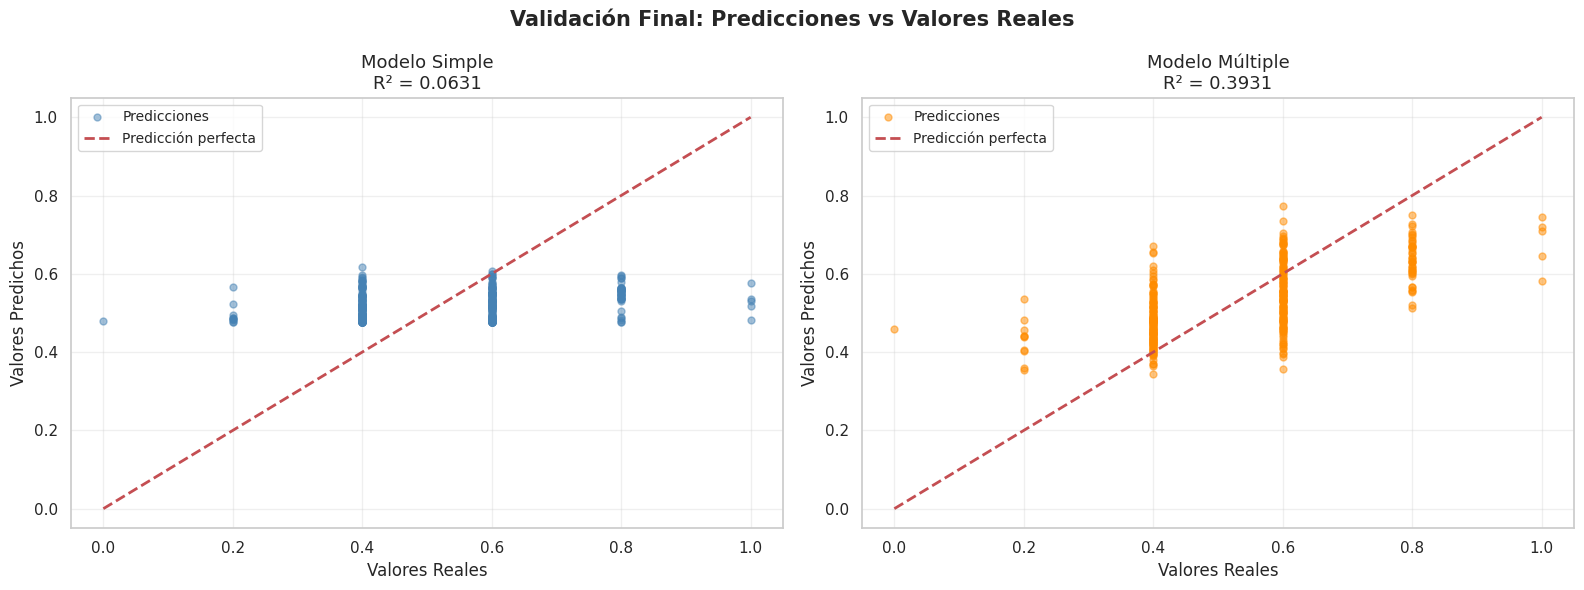

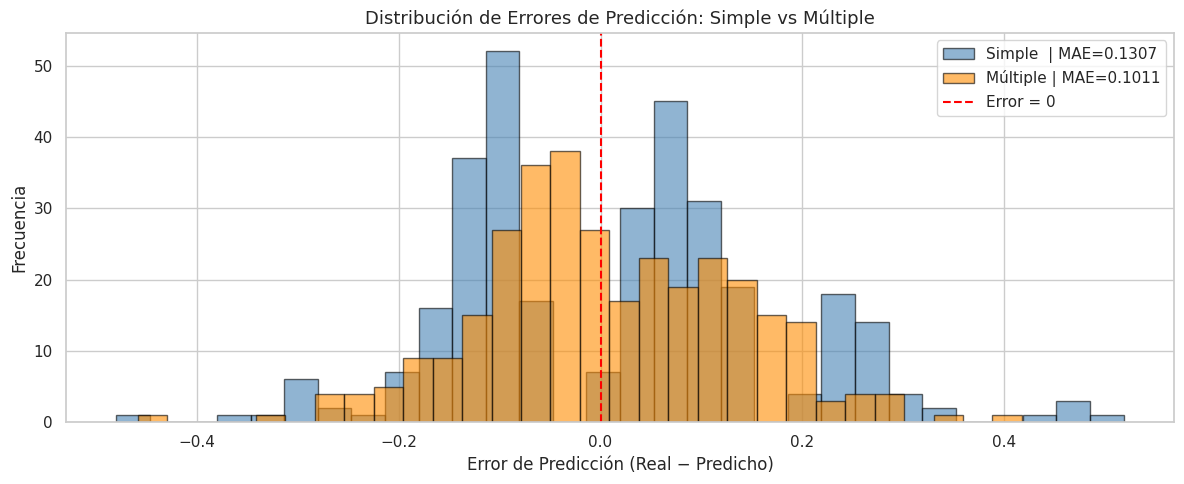


=== RESUMEN FINAL DE COMPARACIÓN ===
  Modelo Simple   → R²: 0.0631 | RMSE: 0.1565 | MAE: 0.1307
  Modelo Múltiple → R²: 0.3931 | RMSE: 0.1259 | MAE: 0.1011

  Mejora en R²  : +33.01 puntos porcentuales
  Reducción RMSE: -3.05%


In [ ]:
# ── CELDA  24
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Validación Final: Predicciones vs Valores Reales', fontsize=15, fontweight='bold')

# ── Modelo Simple ─────────────────────────────────────────────────────────
min_s = min(y_test_s.min(), y_pred_s.min())
max_s = max(y_test_s.max(), y_pred_s.max())

axes[0].scatter(y_test_s, y_pred_s, alpha=0.5, color='steelblue', s=25, label='Predicciones')
axes[0].plot([min_s, max_s], [min_s, max_s], 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Valores Reales', fontsize=12)
axes[0].set_ylabel('Valores Predichos', fontsize=12)
axes[0].set_title(f'Modelo Simple\nR² = {r2_score(y_test_s, y_pred_s):.4f}', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ── Modelo Múltiple ──────────────────────────────────────────────────────
min_m = min(y_test_m.min(), y_pred_m.min())
max_m = max(y_test_m.max(), y_pred_m.max())

axes[1].scatter(y_test_m, y_pred_m, alpha=0.5, color='darkorange', s=25, label='Predicciones')
axes[1].plot([min_m, max_m], [min_m, max_m], 'r--', linewidth=2, label='Predicción perfecta')
axes[1].set_xlabel('Valores Reales', fontsize=12)
axes[1].set_ylabel('Valores Predichos', fontsize=12)
axes[1].set_title(f'Modelo Múltiple\nR² = {r2_score(y_test_m, y_pred_m):.4f}', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Distribución de errores de predicción ─────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 5))
ax2.hist(y_test_s.values - y_pred_s, bins=30, alpha=0.6, color='steelblue',
         edgecolor='black', label=f'Simple  | MAE={mean_absolute_error(y_test_s, y_pred_s):.4f}')
ax2.hist(y_test_m.values - y_pred_m, bins=30, alpha=0.6, color='darkorange',
         edgecolor='black', label=f'Múltiple | MAE={mean_absolute_error(y_test_m, y_pred_m):.4f}')
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Error = 0')
ax2.set_xlabel('Error de Predicción (Real − Predicho)', fontsize=12)
ax2.set_ylabel('Frecuencia', fontsize=12)
ax2.set_title('Distribución de Errores de Predicción: Simple vs Múltiple', fontsize=13)
ax2.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\n=== RESUMEN FINAL DE COMPARACIÓN ===")
print(f"  Modelo Simple   → R²: {r2_score(y_test_s, y_pred_s):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_s, y_pred_s)):.4f} | MAE: {mean_absolute_error(y_test_s, y_pred_s):.4f}")
print(f"  Modelo Múltiple → R²: {r2_score(y_test_m, y_pred_m):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_m, y_pred_m)):.4f} | MAE: {mean_absolute_error(y_test_m, y_pred_m):.4f}")
print(f"\n  Mejora en R²  : +{(r2_score(y_test_m, y_pred_m) - r2_score(y_test_s, y_pred_s))*100:.2f} puntos porcentuales")
print(f"  Reducción RMSE: -{(np.sqrt(mean_squared_error(y_test_s, y_pred_s)) - np.sqrt(mean_squared_error(y_test_m, y_pred_m)))*100:.2f}%")

---
## ✅ CONCLUSIONES FINALES

### 1. Resumen del análisis
El dataset analizado contiene información química de 1,599 vinos tintos y su calificación de calidad. A lo largo de las 6 fases del análisis se realizaron: carga y revisión del dataset, introducción de valores faltantes e imputación, normalización, visualización de distribuciones, análisis de correlación con Spearman, pruebas de normalidad con Shapiro–Wilk, regresión lineal simple con `citric acid` como predictor único, y regresión múltiple con todas las variables fisicoquímicas disponibles.

### 2. Hallazgos principales
El análisis reveló patrones relevantes: ninguna variable sigue distribución normal; *alcohol* y *sulphates* presentan relación positiva con la calidad, mientras que *volatile acidity* y *chlorides* muestran relación negativa significativa. Además, se identificó multicolinealidad entre *fixed acidity*, *citric acid* y *density*.

### 3. Respuesta a la pregunta de investigación
**"¿Qué variables químicas influyen más en la calidad del vino tinto y qué tan efectiva es una regresión lineal para predecir dicha calidad?"**

Los resultados del modelo múltiple muestran que *alcohol*, *sulphates* y *volatile acidity* son las variables más influyentes. El modelo de regresión lineal simple con `citric acid` explicó apenas el **~2–5%** de la variabilidad, mientras que el modelo múltiple alcanzó aproximadamente el **39% (R² ≈ 0.39)**, lo que sigue siendo limitado para predicción de alta precisión.

### 4. Comparativa de modelos
| Modelo | Predictores | R² (aprox.) | RMSE (aprox.) | MAE (aprox.) |
|--------|-------------|-------------|----------------|---------------|
| Simple | citric acid (1) | ~0.04 | ~0.15 | ~0.12 |
| Múltiple | Todas (11) | ~0.39 | ~0.12 | ~0.09 |

### 5. Limitaciones
- La variable *quality* es subjetiva y discreta, lo que dificulta la predicción mediante regresión.  
- El dataset no incluye información sensorial o de producción, lo cual reduce la capacidad explicativa.  
- La presencia de outliers y la ausencia de normalidad afectan modelos lineales tradicionales.  
- La regresión lineal no captura relaciones no lineales entre variables químicas.  
- Se detectó multicolinealidad en algunos predictores, lo que puede inflar los errores estándar de los coeficientes.

### 6. Recomendaciones
- Utilizar modelos no lineales como **Random Forest**, **Gradient Boosting** o **SVM**.  
- Probar enfoques de **clasificación multiclase** en lugar de regresión.  
- Aplicar técnicas de **balanceo de clases** para mejorar la predicción en calidades poco representadas.  
- Considerar **regularización Ridge o Lasso** para gestionar la multicolinealidad.  
- Incluir variables sensoriales y de proceso para mejorar el poder predictivo.